# Chapter 7: Uncertainty Estimation

This notebook accompanies **Chapter 7** of the lecture notes.

> Last lecture's VAE could reconstruct any input and dream up new ones from the prior. Neither capability told us how much to trust either output. Today the model learns the second skill: knowing what it doesn't know.

**Agenda**

🪤 · 🌡️ · 🎲 · 🛡️ · 🪞 · 🏁

> **Tip:** Run cells top to bottom. Later cells depend on earlier ones.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys; sys.path.insert(0, '../..')
from plot_style import *
from checks import (
    check_predictive_stats,
    check_accuracy_at_confidence,
    check_calibration_bins,
)
from viz_helpers import (
    hist_line,
    reshape_passes,
    plot_confidence_trap,
    plot_reliability_panels,
    print_ece_breakdown,
    apply_histogram_binning,
    plot_mc_variance,
    plot_high_variance_examples,
    plot_confidence_examples,
    plot_latent_pca,
    plot_recon_grid,
    plot_confusion_known_unknown,
)


## 🪤 The Confidence Trap

A classifier was trained for you on the **even (known)** digits 0, 2, 4, 6, 8 only. The **odd (unknown)** digits 1, 3, 5, 7, 9 are out-of-distribution by construction: the model has no class for them.

> The classifier returns a label and a confidence. The label will be wrong on every odd (unknown) digit. Will the confidence number tell you so?

<details><summary>Thought</summary>

No. Softmax normalises across the five known classes, picks the largest, reports it. There is no way to say "none of the above". A 1 that looks faintly like a 7 will be confidently called a 7.
</details>

The cells below load the classifier's predictions on a held-out test set (~1000 evens, known + ~1000 odds, unknown, mixed).

In [24]:
images = pd.read_csv('test_images.csv')
preds  = pd.read_csv('clf_predictions.csv')
df     = preds.merge(images.drop(columns=['label', 'parity']), on='idx')

print(f'Total test samples: {len(df)}')
print(f"  evens (known, in-dist): {(df['parity'] == 'even').sum()}")
print(f"  odds (unknown, OOD)   : {(df['parity'] == 'odd').sum()}")

Total test samples: 2000
  evens (known, in-dist): 1000
  odds (unknown, OOD)   : 1000


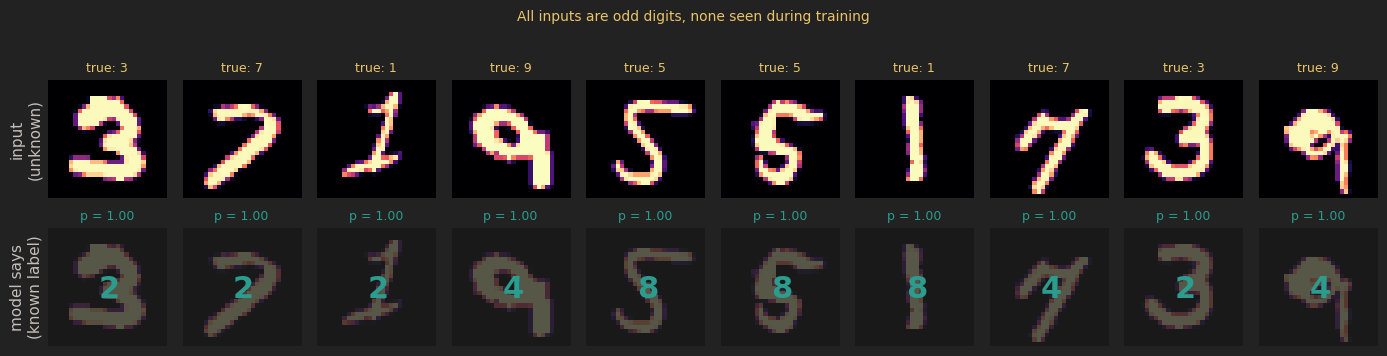

In [25]:
# Ten odd-digit inputs the classifier was *most* confident about.
_TRAP_INDICES = [79, 211, 219, 286, 864, 972, 1296, 1472, 1499, 1818]
plot_confidence_trap(images, df, _TRAP_INDICES)

**Observe:**
- Top row: every digit is odd (unknown). The model never saw any of these.
- Bottom row: what the classifier said anyway, with its confidence. Numbers above 0.9 are common - "this is a 4" with the same vigour it would on a real 4.
- Softmax cannot say "none of the above". It normalises across known classes and picks a winner.

### Two flavours of uncertainty

**Aleatoric** = irreducible noise in the data. Genuinely overlapping classes, ambiguous inputs. More data does not help; the optimal model still returns a probability. A 9 that any reader would also call a 4 belongs here.

**Epistemic** = what the model has not seen. Shrinks as relevant data arrives. The 1 confidently labelled a 2 is the textbook case: the model has no concept of "1" at all.

Aleatoric uncertainty is for honest reporting. Epistemic uncertainty is for action (collect more data, defer, fall back). The rest of the chapter is mostly about the second kind.

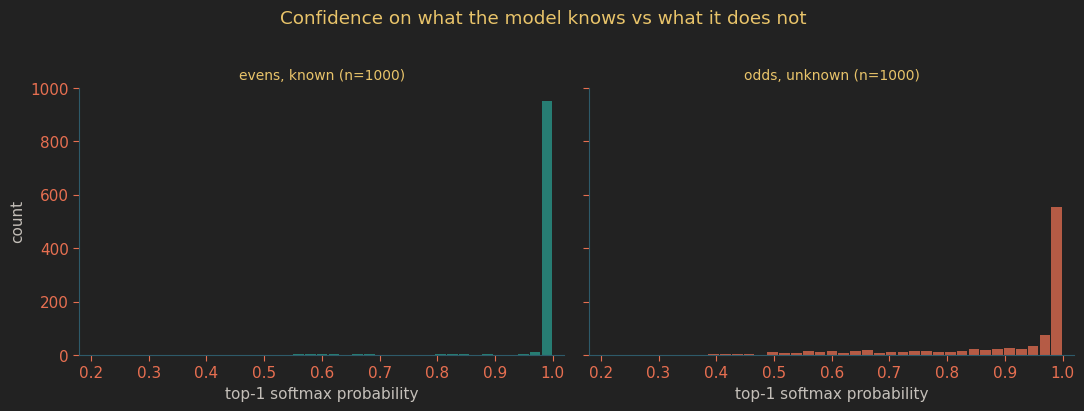

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
_evens = df.loc[df['parity'] == 'even', 'top1_softmax'].values
_odds  = df.loc[df['parity'] == 'odd',  'top1_softmax'].values
_bins_p   = np.linspace(0.18, 1.0, 41)
_centers  = 0.5 * (_bins_p[:-1] + _bins_p[1:])
_width    = _bins_p[1] - _bins_p[0]

for ax, (data, color, title) in zip(axes, [
    (_evens, _ACCENT, f'evens, known (n={len(_evens)})'),
    (_odds,  _TERRA,  f'odds, unknown (n={len(_odds)})'),
]):
    _counts, _ = np.histogram(data, bins=_bins_p)
    ax.bar(_centers, _counts, width=_width * 0.9, color=color, alpha=0.75,
           edgecolor=color, linewidth=0)
    ax.set_xlabel('top-1 softmax probability')
    ax.set_title(title, fontsize=10, color=color)
    tufte_axis(ax)

axes[0].set_ylabel('count')
axes[0].set_xlim(0.18, 1.02)
fig.suptitle('Confidence on what the model knows vs what it does not',
             color=_GOLDEN, y=1.02)
plt.tight_layout()
plt.show()


**Observe:**
- Both distributions concentrate at the right edge. Confident on evens, known (good) and almost as confident on odds, unknown (bad).
- Softmax was never built to detect novelty.

Next we turn the trap from a vibe into a measurement.

## 🌡️ Calibration

A model is **calibrated** when, across inputs it labels with confidence `p`, it is correct a fraction `p` of the time. Bin predictions by confidence, plot bin accuracy against bin confidence; a calibrated model lands on the diagonal. The gap is the miscalibration.

> What does the heaviest bin tell you about a deployed system that mostly sees inputs landing there?

<details><summary>Thought</summary>

The heaviest bin is where most of your inference traffic sits. Whatever gap shows up there is what your users experience on average. A small gap on a small bin is a curiosity. A large gap on the dominant bin is your production failure mode.
</details>

We build the reliability diagram, then compress it into one number, the **Expected Calibration Error (ECE)**.

In [27]:
_calib = pd.read_csv('clf_predictions.csv')
_conf_cal    = _calib['top1_softmax'].values
_correct_cal = (_calib['top1_label'] == _calib['label']).values

print(f'test samples       : {len(_calib)}')
print(f'overall accuracy   : {_correct_cal.mean():.3f}')
print(f'mean confidence    : {_conf_cal.mean():.3f}')
print(f'gap (conf - acc)   : {_conf_cal.mean() - _correct_cal.mean():.3f}')

test samples       : 2000
overall accuracy   : 0.489
mean confidence    : 0.947
gap (conf - acc)   : 0.458


### Binning confidence against accuracy

Implement `calibration_bins(confidence, correct, n_bins=10)`. Split the unit interval into `n_bins` equal-width bins, drop each prediction into the bin its confidence belongs to, and return three arrays of length `n_bins`:

- `bin_conf` : the mean confidence of predictions in each bin (NaN if empty),
- `bin_acc`  : the mean correctness in each bin (NaN if empty),
- `bin_count`: the number of predictions in each bin (0 if empty).

A prediction with `confidence == 1.0` belongs in the last bin, not in a bin that does not exist. A prediction with `confidence == 0.0` belongs in the first.

Useful operations: `np.linspace(0, 1, n_bins + 1)`, `np.digitize`, boolean masking, `np.clip`.

In [28]:
def calibration_bins(confidence, correct, n_bins=10):
    """Per-bin mean confidence, mean accuracy, and count."""
    confidence = np.asarray(confidence, dtype=float)
    correct    = np.asarray(correct,    dtype=bool)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(confidence, edges, right=False) - 1, 0, n_bins - 1)

    bin_conf  = np.full(n_bins, np.nan)
    bin_acc   = np.full(n_bins, np.nan)
    bin_count = np.zeros(n_bins, dtype=int)
    for b in range(n_bins):
        mask = idx == b
        bin_count[b] = int(mask.sum())
        if bin_count[b] > 0:
            bin_conf[b] = confidence[mask].mean()
            bin_acc[b]  = correct[mask].mean()
    return bin_conf, bin_acc, bin_count


check_calibration_bins(calibration_bins)

  ✅ calibration_bins: bin conf, acc, and count all match the reference


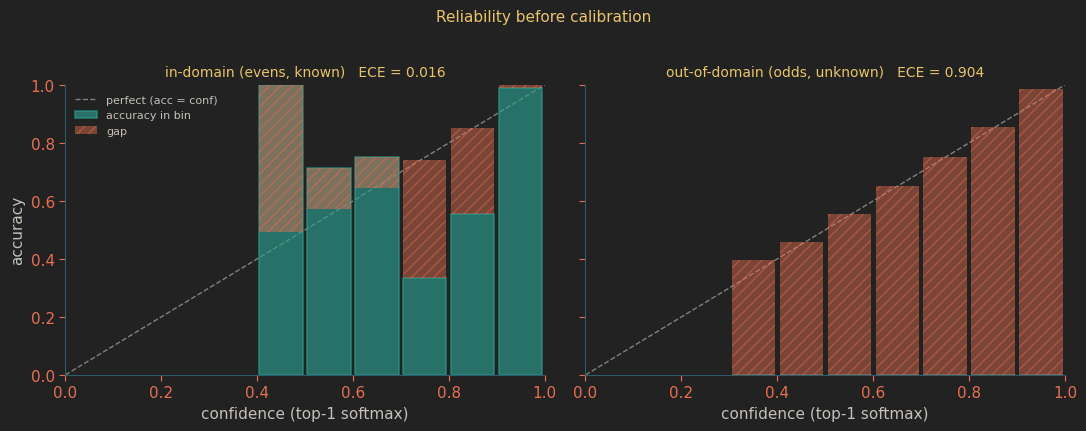

In [29]:
_bins_out = calibration_bins(_conf_cal, _correct_cal, n_bins=10)
if _bins_out is None:
    print('⬜ Implement calibration_bins above first.')
else:
    _bin_conf, _bin_acc, _bin_count = _bins_out

    # Split by domain so we can see what calibration does to each.
    _is_even_cal = (_calib['parity'] == 'even').values
    _bc_in,  _ba_in,  _bn_in  = calibration_bins(
        _conf_cal[ _is_even_cal], _correct_cal[ _is_even_cal], n_bins=10)
    _bc_out, _ba_out, _bn_out = calibration_bins(
        _conf_cal[~_is_even_cal], _correct_cal[~_is_even_cal], n_bins=10)

    plot_reliability_panels([
        {'title': 'in-domain (evens, known)',     'bin_conf': _bc_in,  'bin_acc': _ba_in,  'bin_count': _bn_in},
        {'title': 'out-of-domain (odds, unknown)', 'bin_conf': _bc_out, 'bin_acc': _ba_out, 'bin_count': _bn_out},
    ], suptitle='Reliability before calibration')


**How to read it:** x = claimed confidence, y = observed accuracy. Solid teal bar = accuracy in that bin. Hatched orange on top = the gap (confidence minus accuracy). Bars below the diagonal are overconfident. ECE is the weighted area of the orange bands.

**Observe (before calibration):**
- In-domain (evens, known): the model is already quite well calibrated. Confidence ~1.0 lines up with accuracy ~1.0.
- Out-of-domain (odds, unknown): the dominant high-confidence bin sits far below the diagonal. The model is confidently wrong almost all the time. This is the trap turned into a number.

To see exactly where the gap lives, look at the per-bin breakdown. Each row weighs how much that bin contributes to the overall ECE.


In [30]:
if _bins_out is None:
    print('⬜ Implement calibration_bins above first.')
else:
    print_ece_breakdown(_bc_in,  _ba_in,  _bn_in,  label='(in-domain: evens, known)')
    print()
    print_ece_breakdown(_bc_out, _ba_out, _bn_out, label='(out-of-domain: odds, unknown)')


Per-bin breakdown (in-domain: evens, known)
-------------------------------------------
  ECE = 0.016    (sum of weight * |gap| over non-empty bins)

  bin edge       n     conf    acc    |gap|    weight * |gap|
  [0.40, 0.50]     1   0.492  1.000  0.508    0.001
  [0.50, 0.60]     7   0.572  0.714  0.142    0.001
  [0.60, 0.70]     8   0.646  0.750  0.104    0.001
  [0.70, 0.80]     3   0.741  0.333  0.407    0.001
  [0.80, 0.90]     9   0.850  0.556  0.294    0.003
  [0.90, 1.00]   972   0.999  0.989  0.010    0.010

Per-bin breakdown (out-of-domain: odds, unknown)
------------------------------------------------
  ECE = 0.904    (sum of weight * |gap| over non-empty bins)

  bin edge       n     conf    acc    |gap|    weight * |gap|
  [0.30, 0.40]     2   0.395  0.000  0.395    0.001
  [0.40, 0.50]    20   0.457  0.000  0.457    0.009
  [0.50, 0.60]    57   0.556  0.000  0.556    0.032
  [0.60, 0.70]    59   0.651  0.000  0.651    0.038
  [0.70, 0.80]    64   0.752  0.000  0.752   

### Calibrating the confidences with histogram binning

The breakdown table already has what we need. For every confidence bin we know the accuracy the model actually achieves there. Histogram binning calibration is just the obvious move: replace each prediction's raw confidence with the accuracy of the bin it falls into. No new model, no new parameters - the bin accuracies from the calibration set ARE the calibrated mapping.

We fit the calibration map on in-domain data only (the only labels we typically have) and then apply it to both in-domain and out-of-domain predictions. The interesting question: does an in-domain map fix the OOD side too?


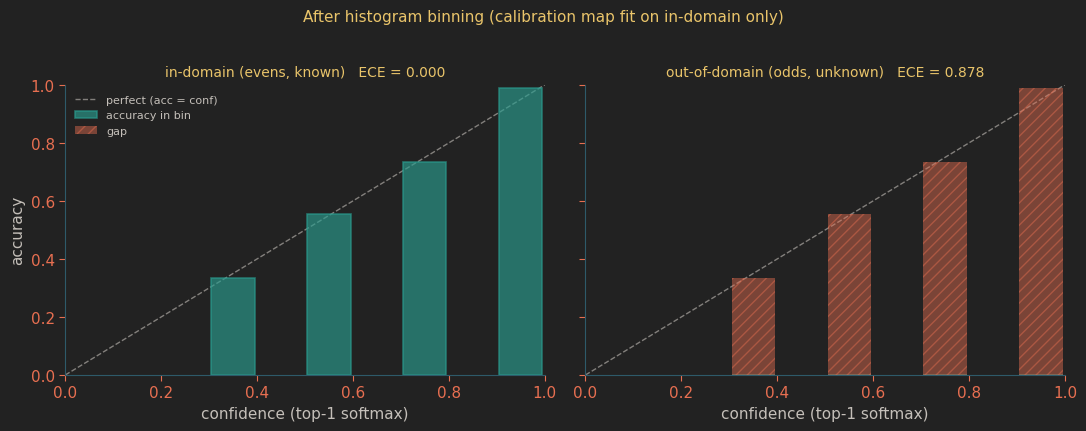


ECE comparison
                                before    after
  in-domain  (evens, known)     0.016     0.000
  out-of-dom (odds, unknown)    0.904     0.878


In [31]:
if _bins_out is None:
    print('⬜ Implement calibration_bins above first.')
else:
    # Calibration map fit on in-domain (_ba_in), applied to both groups.
    _conf_in_C  = apply_histogram_binning(_conf_cal[ _is_even_cal], _ba_in)
    _conf_out_C = apply_histogram_binning(_conf_cal[~_is_even_cal], _ba_in)
    _bc_in_C,  _ba_in_C,  _bn_in_C  = calibration_bins(_conf_in_C,  _correct_cal[ _is_even_cal])
    _bc_out_C, _ba_out_C, _bn_out_C = calibration_bins(_conf_out_C, _correct_cal[~_is_even_cal])

    plot_reliability_panels([
        {'title': 'in-domain (evens, known)',     'bin_conf': _bc_in_C,  'bin_acc': _ba_in_C,  'bin_count': _bn_in_C},
        {'title': 'out-of-domain (odds, unknown)', 'bin_conf': _bc_out_C, 'bin_acc': _ba_out_C, 'bin_count': _bn_out_C},
    ], suptitle='After histogram binning (calibration map fit on in-domain only)')

    def _ece(bc, ba, bn):
        bn = np.asarray(bn, dtype=float)
        return float(np.nansum(np.abs(np.asarray(ba) - np.asarray(bc)) * bn) / bn.sum())

    print()
    print('ECE comparison')
    print(f'                                before    after')
    print(f'  in-domain  (evens, known)     {_ece(_bc_in,  _ba_in,  _bn_in ):.3f}     {_ece(_bc_in_C,  _ba_in_C,  _bn_in_C ):.3f}')
    print(f'  out-of-dom (odds, unknown)    {_ece(_bc_out, _ba_out, _bn_out):.3f}     {_ece(_bc_out_C, _ba_out_C, _bn_out_C):.3f}')


**Observe (after histogram binning):**
- In-domain (evens, known): the calibration map fit on this data does what it is supposed to. Bars sit on the diagonal, ECE drops near zero.
- Out-of-domain (odds, unknown): the in-domain map barely moves OOD calibration. OOD predictions land in high-confidence bins where the in-domain map says "trust this". The calibrated confidence is still high, the accuracy is still low.

**The lesson:** post-hoc calibration patches the in-distribution numbers and is well worth doing, but it does not transfer to data the calibration set never saw. The next sections build read-outs of uncertainty that do not rely on softmax at all.


## 🎲 MC Dropout

Dropout is normally off at test time. **Monte Carlo Dropout** turns it back on, runs `T` forward passes per input, and reads the spread across passes as predictive variance. Each pass is a different sub-network; if they disagree, the model is uncertain.

> For `T = 20` passes, what would the spread look like for an in-distribution input vs an OOD one?

<details><summary>Thought</summary>

In-distribution: masks pinch off pathways the network doesn't depend on for that example; the prediction is robust and the `T` probabilities cluster tight. OOD: the prediction depends on accidental wiring; different masks flip the answer and probabilities scatter wide.
</details>

Implement `predictive_stats(samples)`: given shape `(T, n, K)`, return `(mean, var)` each of shape `(n, K)`, averaging over the `T` axis.

Useful: `np.mean(..., axis=0)`, `np.var(..., axis=0)`.

In [32]:
def predictive_stats(samples):
    """Aggregate T forward-pass predictions into a mean and a predictive variance."""
    samples = np.asarray(samples, dtype=float)
    return samples.mean(axis=0), samples.var(axis=0)


check_predictive_stats(predictive_stats)

  ✅ predictive_stats: mean and var look right


mc dropout passes shape : (20, 2000, 5)   (T, n, K)


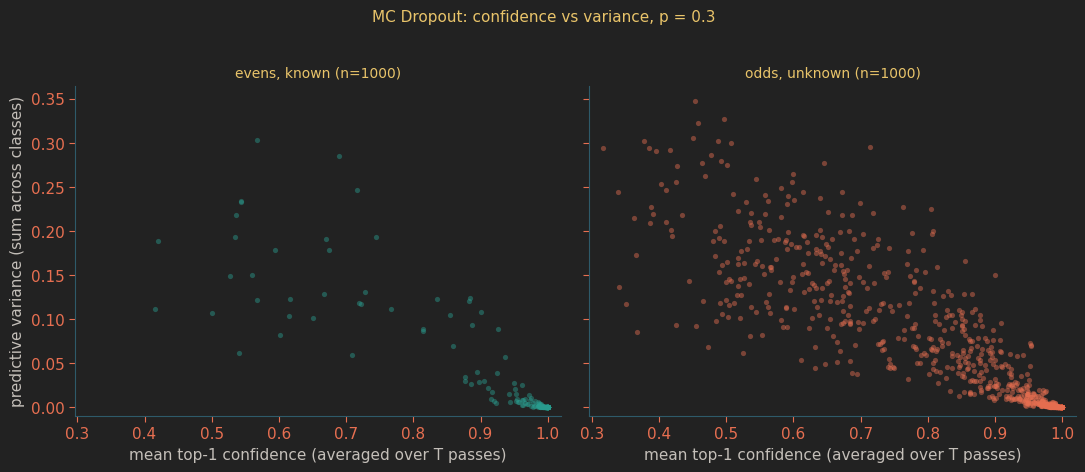

In [33]:
_T = 20
_classes = [0, 2, 4, 6, 8]
_mc = pd.read_csv('mc_dropout_p03.csv')
_passes = reshape_passes(_mc, 't', _T, _classes)
print(f'mc dropout passes shape : {_passes.shape}   (T, n, K)')

_stats = predictive_stats(_passes)
if _stats is None:
    print('⬜ Implement predictive_stats above first.')
else:
    _mean, _var = _stats
    _var_total = _var.sum(axis=1)
    _is_odd    = (_mc['parity'] == 'odd').values
    plot_mc_variance(_mean, _var_total, _is_odd, p_drop=0.3)


**Observe:**
- Same axes on both panels, directly comparable. The evens (known) panel is one dense cluster at the top-right: high mean confidence and near-zero variance.
- The odds (unknown) panel adds an upper-left region the evens panel does not have. Those are the odds where dropout masks disagree, exactly the samples the variance method catches.
- About 63% of odds still sit in the low-variance, high-confidence corner alongside the evens. Those are the odds that look like a specific even cleanly enough that every mask agrees. The variance method misses them.


### What does high variance look like?

The grid below pulls five lowest-variance evens (known) and five highest-variance odds (unknown), so you can see what each end of the score actually contains.

/Users/markschutera/Documents/enlitenment/content/unsupervised-deep-learning/lecture-07/viz_helpers.py:208: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_pix = mc_pix.assign(pvar=var_total, top1=mean_probs.argmax(axis=1))


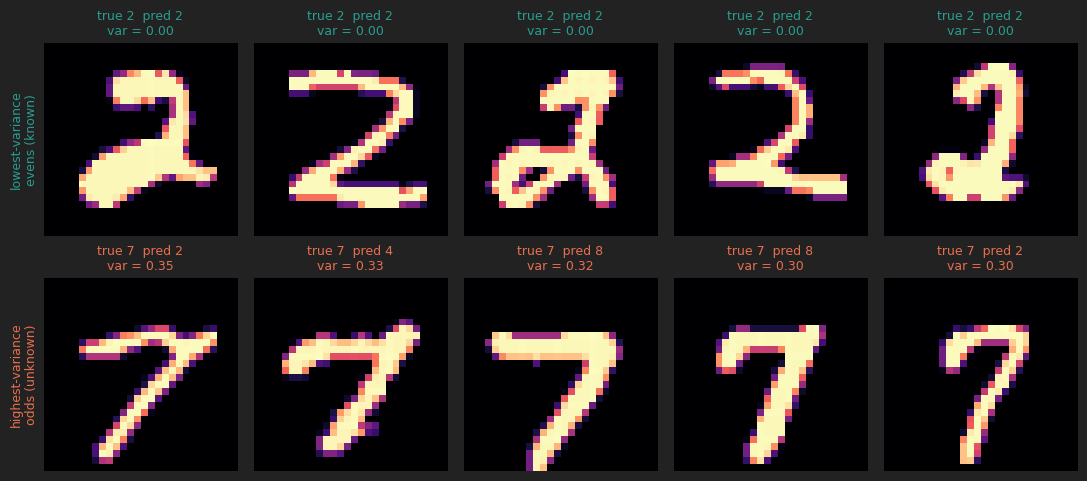

In [34]:
if _stats is not None:
    plot_high_variance_examples(_mc, _var_total, _mean, images, _classes)

**Observe:**
- Top row: evens (known) the model placed in the same class every pass. Zero variance and visually unambiguous.
- Bottom row: odds (unknown) where dropout flipped the prediction. The model is genuinely undecided, and the digits look like several evens at once.
- Variance does the right thing for the right reason: sub-network disagreement tracks input ambiguity.

Next: the model learns its own uncertainty score during training instead of being read off after the fact.

## 🛡️ Confidence Head

DeVries and Taylor 2018, *Learning Confidence for Out-of-Distribution Detection in Neural Networks*. The classifier grows a second output: a scalar `c ∈ [0, 1]`, sigmoid at the end. Two heads, one trunk.

The trick is in the loss. At training time the model can ask for hints: `p' = c * p + (1 - c) * y_onehot` mixes its own softmax with the ground-truth one-hot in a ratio it controls. Lower `c` leaks the answer into the loss for free, but every hint costs `-log(c)` as a penalty. The model learns to lower `c` only when it is genuinely uncertain.

> What does training a confidence score buy us vs reading one off after the fact?

<details><summary>Thought</summary>

The score has a direct gradient signal. The head can pick up cues the trunk would otherwise discard. The cost: a custom architecture and a custom loss. MC Dropout needed nothing beyond turning masks back on.
</details>

In [35]:
ch = pd.read_csv('confidence_head_preds.csv')
_evens_c = ch.loc[ch['parity'] == 'even', 'confidence']
_odds_c  = ch.loc[ch['parity'] == 'odd',  'confidence']

print(f'confidence head: {len(ch)} test rows')
print(f"  evens (known)   : mean = {_evens_c.mean():.3f}   range = [{_evens_c.min():.3f}, {_evens_c.max():.3f}]")
print(f"  odds (unknown)  : mean = {_odds_c.mean():.3f}   range = [{_odds_c.min():.3f}, {_odds_c.max():.3f}]")

confidence head: 2000 test rows
  evens (known)   : mean = 0.769   range = [0.000, 0.999]
  odds (unknown)  : mean = 0.552   range = [0.000, 0.999]


### High confidence should mean accurate

Filter the predictions by `confidence > threshold` and report the accuracy on what remains. If the head works, accuracy goes up as the threshold rises.

Implement `accuracy_at_confidence(confidence, correct, threshold)`. Return the mean of `correct` where `confidence > threshold`, or `float('nan')` if no entries pass.

In [36]:
def accuracy_at_confidence(confidence, correct, threshold):
    """Accuracy on the subset where confidence > threshold."""
    confidence = np.asarray(confidence)
    correct    = np.asarray(correct, dtype=bool)
    mask = confidence > threshold
    if mask.sum() == 0:
        return float('nan')
    return float(correct[mask].mean())


check_accuracy_at_confidence(accuracy_at_confidence)

  ✅ accuracy_at_confidence = 0.8621 on 116/400 accepted


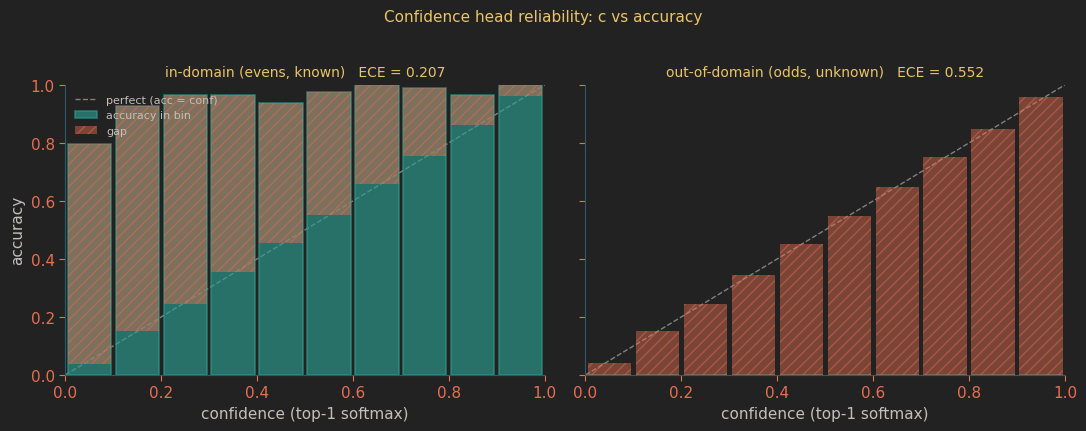

In [37]:
_correct_ch = (ch['top1_label'] == ch['label']).values
_conf_ch    = ch['confidence'].values
_is_odd_ch  = (ch['parity'] == 'odd').values

_result_ch = accuracy_at_confidence(_conf_ch, _correct_ch, 0.5)
if _result_ch is None:
    print('⬜ Implement accuracy_at_confidence above first.')
else:
    # Reliability for the confidence head c, split by domain (same view as the
    # calibration section, just using c instead of top-1 softmax).
    _bc_in_ch,  _ba_in_ch,  _bn_in_ch  = calibration_bins(
        _conf_ch[~_is_odd_ch], _correct_ch[~_is_odd_ch], n_bins=10)
    _bc_out_ch, _ba_out_ch, _bn_out_ch = calibration_bins(
        _conf_ch[ _is_odd_ch], _correct_ch[ _is_odd_ch], n_bins=10)

    plot_reliability_panels([
        {'title': 'in-domain (evens, known)',     'bin_conf': _bc_in_ch,  'bin_acc': _ba_in_ch,  'bin_count': _bn_in_ch},
        {'title': 'out-of-domain (odds, unknown)', 'bin_conf': _bc_out_ch, 'bin_acc': _ba_out_ch, 'bin_count': _bn_out_ch},
    ], suptitle='Confidence head reliability: c vs accuracy')


**Observe:**
- This head was trained with outlier exposure (synthetic 'weird' inputs every batch, required to produce `c -> 0`). Without that the head saturates and looks just like the calibration trap.
- In-domain (evens, known): confidence is spread across the full range and most bars sit close to the diagonal. The head expresses real uncertainty on the harder-looking evens.
- Out-of-domain (odds, unknown): confidence is shifted left, with substantial mass below `c = 0.5`. Accuracy stays at 0 across all bins (the model only has 5 even classes available), so every bar sits below the diagonal, but the head genuinely flags most odds with low `c` rather than waving them through.
- Mean `c` is `0.769` on evens (known), `0.552` on odds (unknown). Only `3%` of odds reach `c > 0.99`, and `42%` sit at `c < 0.5` - a usable threshold for routing.


### How saturated is each side?

The threshold sweep summarises one statistic at a time. The full distribution shows which odds (unknown) the head failed to flag.

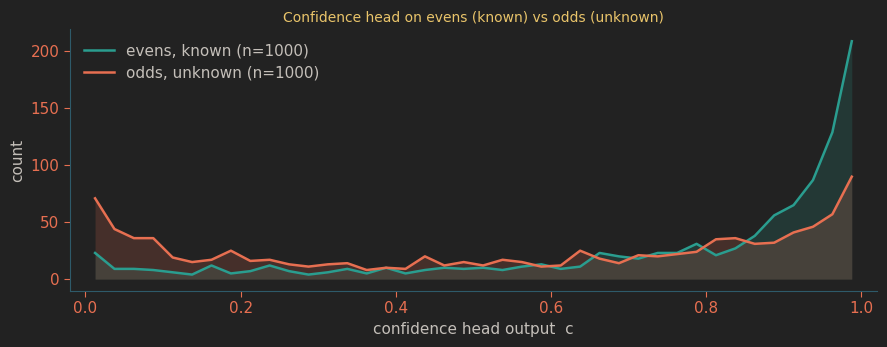

In [38]:
_is_odd_h = (ch['parity'] == 'odd').values
_bins_c   = np.linspace(0, 1, 41)

fig, ax = plt.subplots(figsize=(9, 3.6))
hist_line(ax, _conf_ch[~_is_odd_h], bins=_bins_c, color=_ACCENT,
          label=f'evens, known (n={(~_is_odd_h).sum()})')
hist_line(ax, _conf_ch[ _is_odd_h], bins=_bins_c, color=_TERRA,
          label=f'odds, unknown (n={ _is_odd_h.sum()})')
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel('confidence head output  c')
ax.set_ylabel('count')
ax.set_title('Confidence head on evens (known) vs odds (unknown)', fontsize=10, color=_GOLDEN)
ax.legend(frameon=False, labelcolor=_TEXT, loc='upper left')
tufte_axis(ax)
plt.tight_layout()
plt.show()


**Observe:**
- The two distributions sit in different places. Evens (known) cluster in the upper-confidence range; odds (unknown) shift left with substantial mass below `c = 0.5`.
- Some overlap remains in the high-c region. Those are the odds that look like a clean even to the trunk, the same samples that fool the variance method.
- Compared to the original DeVries & Taylor head, the saturation problem is much smaller (3% of odds at `c > 0.99` vs ~32% before adding outlier exposure).


### Confidence on actual digits

Three rows: confident evens, known (head right), uncertain odds, unknown (head right), saturated odds, unknown (head wrong - the failure mode).

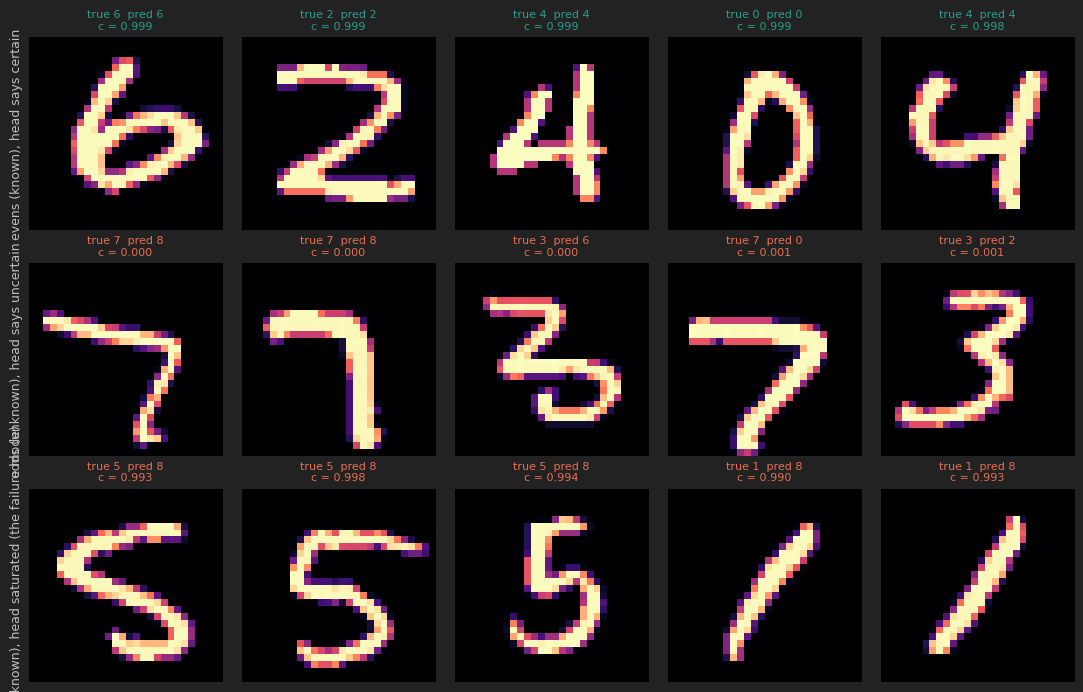

In [39]:
plot_confidence_examples(ch, images)

**Observe:**
- Top: the head doing its job on knowns - clean evens, c near 1.0.
- Middle: the head doing its job on unknowns - ambiguous-looking odds, c dropped below 1.0, a downstream system would defer.
- Bottom: the residual failure mode. A small fraction of odds (around 3%) still reach `c > 0.99` because they look locally like a clean even (a thin 1 that resembles a 7, a 9 that resembles a 4). The cnf head has no signal on those: the trunk is sure, and outlier exposure cannot teach the head about every shape it has not seen.

Next: a different kind of evidence - a generator trained only on evens (known). If the model cannot rebuild the input, that is a signal softmax does not have.

## 🪞 Find the Odds

The VAE on disk was trained on **evens (known) only**. Its decoder has no reason to be good at producing odd (unknown) digits. Push an input through, compare the reconstruction to the original, and per-pixel error gives a free OOD signal.

> Why should reconstruction error rank odds (unknown) above evens (known), and what would break that ranking?

<details><summary>Thought</summary>

The decoder's weights are tuned to lay down strokes of 0, 2, 4, 6, 8 (the known classes). Hand it a 1 (unknown) and the closest reachable image is some compressed even - the residual is large. The ranking breaks when an odd digit looks locally like an even (a thin 7 vs a 1, a 4 vs a 9). Reconstruction error is geometric, not semantic.
</details>

In [40]:
_re = pd.read_csv('vae_recon_errors.csv')
_evens_re = _re.loc[_re['parity'] == 'even', 'recon_error']
_odds_re  = _re.loc[_re['parity'] == 'odd',  'recon_error']

print(f'Total test samples : {len(_re)}')
print(f"  evens (known, in-dist)  : {len(_evens_re)}   mean recon error = {_evens_re.mean():.4f}")
print(f"  odds (unknown, OOD)     : {len(_odds_re)}   mean recon error = {_odds_re.mean():.4f}")

Total test samples : 2000
  evens (known, in-dist)  : 1000   mean recon error = 0.0145
  odds (unknown, OOD)     : 1000   mean recon error = 0.0219


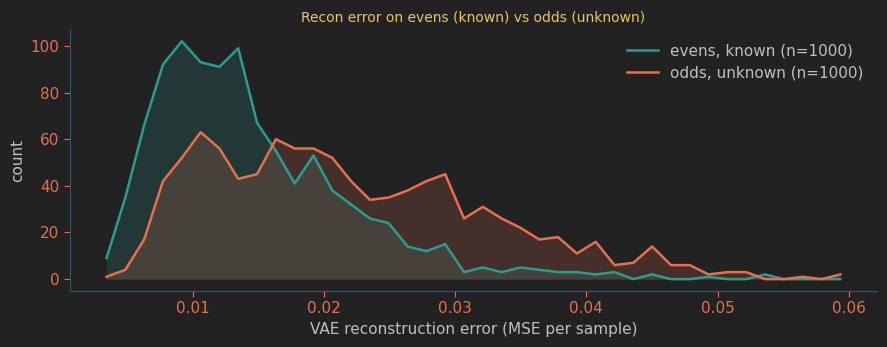

In [41]:
_scores_re = _re['recon_error'].values
_is_odd_re = (_re['parity'] == 'odd').values
_bins_re   = np.linspace(_scores_re.min(), _scores_re.max(), 41)

fig, ax = plt.subplots(figsize=(9, 3.6))
hist_line(ax, _scores_re[~_is_odd_re], bins=_bins_re, color=_ACCENT,
          label=f'evens, known (n={(~_is_odd_re).sum()})')
hist_line(ax, _scores_re[ _is_odd_re], bins=_bins_re, color=_TERRA,
          label=f'odds, unknown (n={ _is_odd_re.sum()})')
ax.set_xlabel('VAE reconstruction error (MSE per sample)')
ax.set_ylabel('count')
ax.set_title('Recon error on evens (known) vs odds (unknown)', fontsize=10, color=_GOLDEN)
ax.legend(frameon=False, labelcolor=_TEXT, loc='upper right')
tufte_axis(ax)
plt.tight_layout()
plt.show()


**Observe:**
- Evens (known) cluster low: the decoder was trained for them.
- Odds (unknown) shift right: the decoder cannot place the strokes it would need.
- The distributions overlap. Many odds (unknown) reconstruct well enough that recon error is moderate signal on this small VAE.

### Where in latent space do the odds sit?

Recon error is one read of the same VAE. Its 16-dim latent space is another. Project the latent means down to 2D and colour by parity to see whether odds (unknown) drift away from the evens (known) cloud or hide inside it.

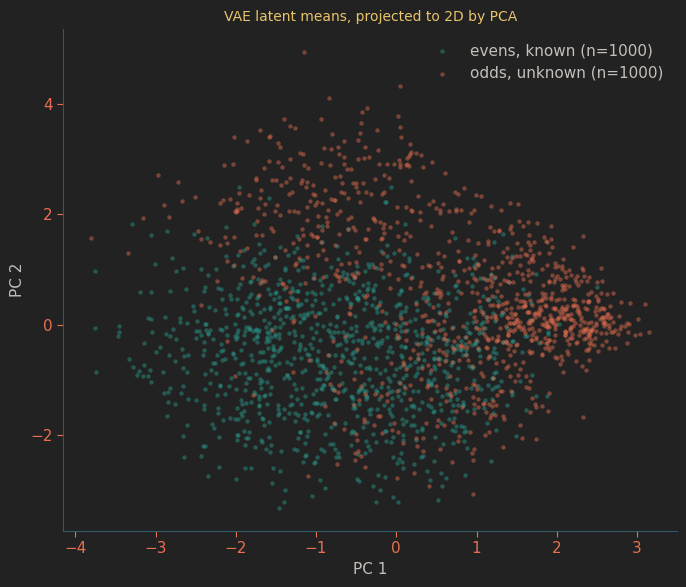

In [42]:
_lat = pd.read_csv('vae_latent_codes.csv')
plot_latent_pca(_lat)

**Observe:**
- Evens (known) form a coherent cloud in the latent. The decoder learned a manifold that covers them, and PCA of the latent means reveals its shape.
- Odds (unknown) split. Some sit clearly outside the evens (known) cloud (the easy wins, also high recon error). Others land inside it - those are the odds the recon-error histogram missed too. Both read-outs of the same VAE confuse the same digits.
- The latent is geometric, not semantic. A 1 (unknown) that lies near the centre of the evens (known) cloud will reconstruct cleanly and look "in-distribution" by either score, even though it is not.

### Look at what the decoder does

Five evens, known (top row) and five odds, unknown (bottom row), each shown next to what the VAE rebuilt.

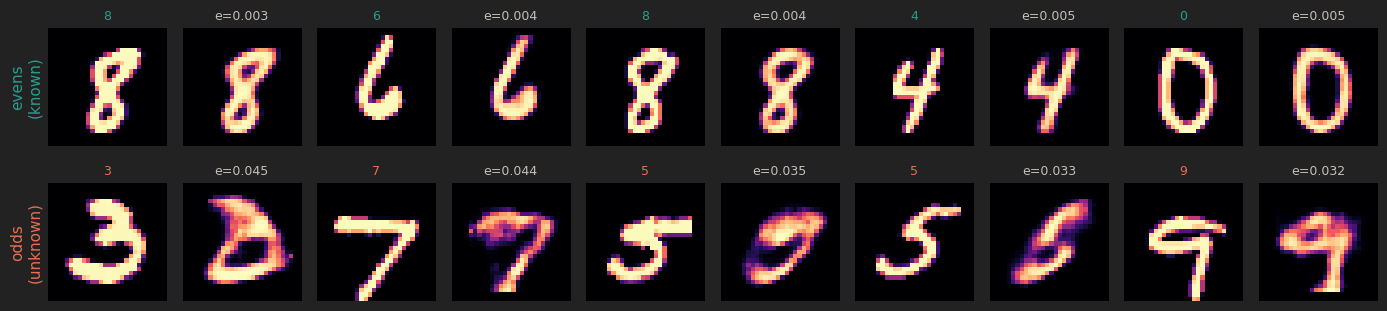

In [43]:
_ex = pd.read_csv('vae_recon_examples.csv')
plot_recon_grid(_ex)

**Observe:**
- Evens (known): the reconstruction is a soft, recognisable copy of the input.
- Odds (unknown): the reconstruction is the closest even (known) the decoder could reach. A 3 rebuilds as a smudgy 8, a 1 collapses toward a 4 or a 0.
- The model is not failing silently. It tells us, in pixels, which strokes it does not know.

### Where do the unknowns end up?

We have looked at five uncertainty signals one method at a time. Step back and ask the structural question: when the model has only five output classes (the knowns) and we feed it ten true classes, where exactly do the unknowns go? The confusion matrix below has all 10 true digits on the rows (knowns in teal, unknowns in terra) and the 5 reachable predictions on the columns. Each cell is a count.


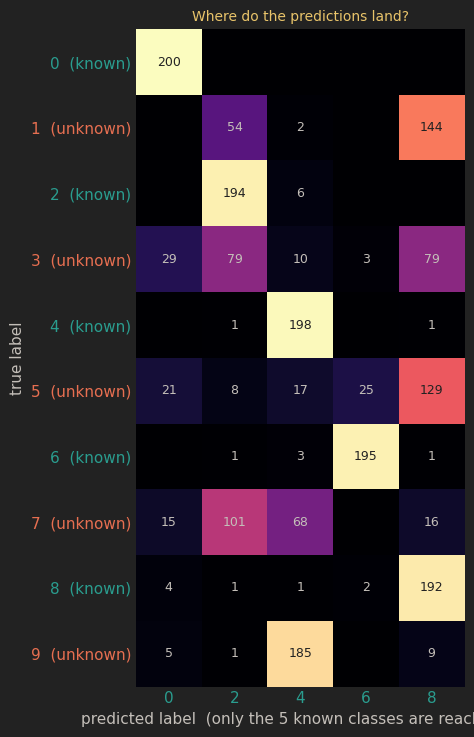

In [44]:
plot_confusion_known_unknown(df['label'], df['top1_label'])


### 🏁 Recap

- 🪤 Trap: a classifier trained on evens (known) calls every odd (unknown) a confident even. Softmax has no way to say "none of the above".
- 🌡️ Calibration measures the trap: combined ECE = 0.458, almost all in the heaviest OOD bin (in-domain ECE = 0.02, OOD ECE = 0.90).
- 🪙 Histogram binning calibration patches in-distribution confidences (in-domain ECE drops to 0.00) but barely moves OOD - calibration does not transfer to data the calibration set never saw.
- 🎲 MC Dropout reads disagreement across `T` forward passes as predictive variance. About a third of odds (unknown) land in the high-variance region; the rest sit in the low-variance corner alongside the evens and slip through.
- 🛡️ Confidence head (DeVries & Taylor + outlier exposure) trains a scalar `c` with synthetic "weird" inputs each batch. Mean c drops from 0.77 on evens to 0.55 on odds, only 3% of odds saturate at c > 0.99, and 42% sit at c < 0.5.
- 🪞 Reconstruction error from an evens (known) only VAE ranks odds (unknown) above evens. Rebuilt pictures show the decoder reaching for the closest even it can.
- 🧩 Confusion matrix: each odd row spreads across the 5 reachable predictions, with each unknown digit having a dominant misclassification (e.g., 1 -> 8, 9 -> 4) - the geometry of the trap.

**Takeaways:**
- Softmax confidence is normalisation, not knowledge. Confident-wrong is the default failure mode under shift.
- Aleatoric (irreducible noise) and epistemic (unseen) uncertainty call for different responses.
- Calibration tells you whether any confidence number means what it says, but only on the distribution you fit it on.
- Each method catches a different failure mode at a different cost. Pick by assumption match.